In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [2]:
import os
os.makedirs("outputs", exist_ok=True)

In [3]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors 

### Q1

In [4]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

# Tensor a 
print("a:", a)
print("shape:",a.shape)
print("dtype:", a.dtype)
print("device:", a.device)

print("\nb:", b)
print("shape:", b.shape)
print("dtype:", b.dtype)
print("device:", b.device)

print("\nc:", c)
print("shape:",c.shape)
print("dtype:", c.dtype)
print("device:", c.device)

# These tensors currently on the CPU

# It uis important that both the model and input tensors are on the same device
# because PyTorch cannot perform operations between CPU and GPU tensors.
# IF they are on different devices, it will cause an error

a: tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

b: tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

c: tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu


### Q2

In [5]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("sqrt:", torch.sqrt(x))
print("sum:", x.sum())
print("mean:", x.mean())
print("argmax:", x.argmax())

# .argmax() returns the class with the highest predicted score.

sqrt: tensor([1., 2., 3., 4., 5.])
sum: tensor(55.)
mean: tensor(11.)
argmax: tensor(4)


### Q3

In [6]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# PyTorch requires .cpu() because NumPy cannot work with GPU tensors.
# NumPy arrays live in CPU memory, not on the GPU

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Q4

In [7]:
t = torch.arange(24).float()

t_reshaped_1 = t.reshape(4,6)
print(t_reshaped_1.shape)

t_reshaped_2 = t.reshape(2, 3, 4)
print(t_reshaped_2.shape)

t_reshaped_3 = t_reshaped_1.unsqueeze(0)
print(t_reshaped_3.shape)

# The operation that accompishes is unsqueeze(0).
# This matters because neural networks are designed to always process inputs in batches
# even when there is only one image.

torch.Size([4, 6])
torch.Size([2, 3, 4])
torch.Size([1, 4, 6])


### Q5

In [8]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

np_math = np.matmul(np_a, np_b)
t_math = torch.matmul(t_a, t_b)

print(np_math)
print(t_math)
print(np.allclose(np_math, t_math.numpy()))

# Matrix multiplication transforms input data into learned features inside a neural network layer.

[[19. 22.]
 [43. 50.]]
tensor([[19., 22.],
        [43., 50.]])
True


## Pretrained Models

## Q1

In [9]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Using pretrained model is very practical because it saves a huge amount of time, data, and computational recources.
# Instead of training ResNet18 from scratch on millions of images, we can start from already learned features 
# and fine-tune the model for our task
# This is especially important when we have limited budget and tight deadline

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


## Q2

In [10]:
print(model)

# The final layer in ResNet-18 is the fully connected (fc) layer.
# Its output size is 1000, corresponding to the 1000 ImageNet classes the model can predict.

# A deep network has many layers (like layer1 to layer4).
# Each layer learns something from the data step by step.
# Early layers find simple things like edges,
# and deeper layers find more complex things like shapes or objects.
# This is why it is called "deep".


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Q3

In [11]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# .to(device) ensures model and data are on the same device so computation works correctly

# model.eval() puts model in prediction mode.
# BatchNorm behave differently in train and eval.

Model ready for inference.


## Q4

In [12]:
preprocess = weights.transforms()
print(preprocess)

# Resize/crop makes all images the same size (e.g., 224x224),
# so they match what the model expects and can be processed without errors.

# ToTensor() changes pixels from 0-255 to 0-1.
# This makes the data easier for neural networks to process.

# Normalization rescales pixel values using mean and std.
# It uses ImageNet values because the model was trained on ImageNet,
# so inputs must match the same distribution for good performance.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [13]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")


Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Q1

In [14]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)

    probs = torch.softmax(output[0], dim=0)
    
    top_probs, top_idxs = torch.topk(probs, 5)

    results=[]
    for prob, idx in zip(top_probs, top_idxs):
        results.append((class_labels[idx], prob.item()))

    return results

img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Yes, the top prediction make sense.
# Several of the top-5 predictions (especially "alp", and "valley") clearly describe a montainous scene.



Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


### Q2

In [15]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# The model seems most confident on classes like "mountain" or "sea", where the visual features are clear
# It is less confident on classes like "street" or "buildings"
# The pattern is that the model performs better on natural scenes and worse on mixed environments.


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


### Q3

In [16]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# Neural networks output logits because they are easier and more stable for computation during training.
# Logits are raw scores that are later converted into probabilities using softmax.

# In a production pipeline, I use probabilities, because they are easier to interpret 
# and allow us to filter predictions based on confidence.

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


### Q4

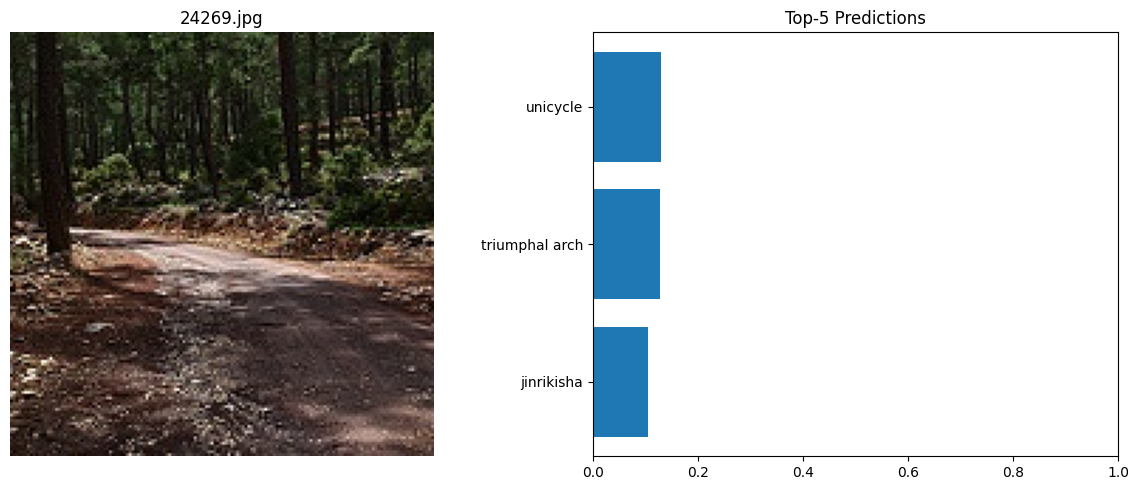

In [17]:
labels = [p[0] for p in preds]
probs = [p[1] for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img)
axes[0].set_title(img_name)
axes[0].axis("off")

axes[1].barh(labels[::-1], probs[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlim(0,1)

plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/warmup_inference_viz.png")

plt.show()

# This visualization is helpful for non-technical people 
# because it shows the image and how sure the model is about its predictions.

# In a real system, we can mark low confidence predictions ( for example, if top-1 probability is less than 0.8)
# so a person can check them.

# A good threshold for automatic decision is usually 0.7 to 0.9. If threshold is higher, it is more safe.
